In [1]:
from datasets import load_dataset

ds = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0"
)

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 54304
    })
})


In [3]:
import pandas as pd

df = ds["train"].to_pandas()
df[["class_label", "host", "disease"]].head()

,class_label,host,disease
0,Apple___Apple_scab,Apple,Apple scab
1,Apple___Apple_scab,Apple,Apple scab
2,Apple___Apple_scab,Apple,Apple scab
3,Apple___Apple_scab,Apple,Apple scab
4,Apple___Apple_scab,Apple,Apple scab


In [4]:
df.shape

(54304, 8)

In [5]:
df["image"].head()

0    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
3    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
Name: image, dtype: object

In [6]:
from IPython.display import display

print(df["class_label"].iloc[0])
display(df["image"])

Apple___Apple_scab


0        {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1        {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2        {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
3        {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4        {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
                               ...                        
54299    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
54300    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
54301    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
54302    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
54303    {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
Name: image, Length: 54304, dtype: object

In [7]:
df["image"].dtype

dtype('O')

In [8]:
type(df["image"].iloc[0])

dict

Apple___Apple_scab


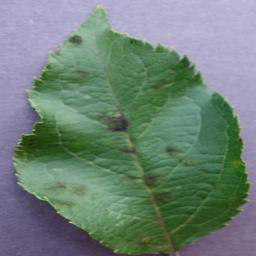

In [9]:
from IPython.display import display
print(ds["train"][0]["class_label"])
display(ds["train"][0]["image"])

In [10]:
train_ds = ds["train"]

print(train_ds)
print(train_ds.features)

Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 54304
})
{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [11]:
sample = train_ds[0]

for key, value in sample.items():
    print(key, ":", value)

image : <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x2059EAFE5D0>
class_label : Apple___Apple_scab
class_idx : 0
host : Apple
disease : Apple scab
split : test
leaf_id : Apple___Apple_scab::leaf_79
leaf_grouped : True


In [12]:
for col in ["class_label", "class_idx", "host", "disease", "split", "leaf_grouped"]:
    print(f"\n{col}")
    print("Unique:", train_ds.unique(col)[:20])
    print("Number of unique:", len(train_ds.unique(col)))


class_label
Unique: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']
Number of unique: 38

class_idx
Unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Number of unique: 38

host
Unique: ['Apple', 'Blueberry', 'Cherry (including sour)', 'Corn (maize)', 'Grape', 'Orange', 'Peach', 'Pepper, bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']
Number of unique: 14

disease
Unique: ['Appl

In [13]:
from collections import Counter

class_counts = Counter(train_ds["class_label"])

for label, count in class_counts.items():
    print(label, ":", count)

Apple___Apple_scab : 630
Apple___Black_rot : 621
Apple___Cedar_apple_rust : 275
Apple___healthy : 1645
Blueberry___healthy : 1502
Cherry_(including_sour)___Powdery_mildew : 1052
Cherry_(including_sour)___healthy : 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513
Corn_(maize)___Common_rust_ : 1192
Corn_(maize)___Northern_Leaf_Blight : 985
Corn_(maize)___healthy : 1162
Grape___Black_rot : 1180
Grape___Esca_(Black_Measles) : 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1076
Grape___healthy : 423
Orange___Haunglongbing_(Citrus_greening) : 5507
Peach___Bacterial_spot : 2297
Peach___healthy : 360
Pepper,_bell___Bacterial_spot : 997
Pepper,_bell___healthy : 1477
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152
Raspberry___healthy : 371
Soybean___healthy : 5090
Squash___Powdery_mildew : 1835
Strawberry___Leaf_scorch : 1109
Strawberry___healthy : 456
Tomato___Bacterial_spot : 2127
Tomato___Early_blight : 1000
Tomato___Late_blight : 1909
Tomato___L

In [14]:
from torchvision import transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
train_ds = ds["train"].filter(lambda x: x["split"] == "train")
test_ds  = ds["train"].filter(lambda x: x["split"] == "test")

In [16]:
train_ds = train_ds.with_transform(
    lambda x: {
        "image": [train_transform(img) for img in x["image"]],
        "class_idx": x["class_idx"]
    }
)

test_ds = test_ds.with_transform(
    lambda x: {
        "image": [test_transform(img) for img in x["image"]],
        "class_idx": x["class_idx"]
    }
)

In [17]:
print(train_ds[0]["image"].shape)
print(train_ds[0]["class_idx"])
sample = train_ds[0]

print(type(sample["image"]))
print(sample["image"].shape)
print(sample["class_idx"])

torch.Size([3, 128, 128])
0
<class 'torch.Tensor'>
torch.Size([3, 128, 128])
0


In [18]:
import torch
import torchvision
def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    labels = torch.tensor([item["class_idx"] for item in batch])

    return images, labels

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [20]:
batch = [train_ds[i] for i in range(3)]

print(type(batch[0]["image"]))
print(type(batch[0]["class_idx"]))

images, labels = collate_fn(batch)

print(type(images))
print(images.shape)
print(type(labels))
print(labels.shape)

<class 'torch.Tensor'>
<class 'int'>
<class 'torch.Tensor'>
torch.Size([3, 3, 128, 128])
<class 'torch.Tensor'>
torch.Size([3])


In [21]:
import torch
import torch.nn as nn

def create_cnn():
    model = nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16, 32, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),

        nn.Linear(32 * 32 * 32, 128),
        nn.ReLU(),
        nn.Linear(128, 38)
    )

    return model

In [22]:
model = create_cnn()

print(model)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=32768, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=38, bias=True)
)


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [24]:
for epoch in range(1):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/5] "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch [1/5] Loss: 0.8758 Accuracy: 0.7435


In [25]:
def predict(model, test_loader):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_predictions

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Test Metrics")
print("--------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

NameError: name 'y_true' is not defined

In [27]:
import torch
import torch.nn as nn

from torchvision.models import resnet18, ResNet18_Weights

In [28]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

In [29]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [30]:
model.fc = nn.Linear(
    model.fc.in_features,
    38
)

In [31]:
for param in model.parameters():
    param.requires_grad = False

model.fc.weight.requires_grad = True
model.fc.bias.requires_grad = True

In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [33]:
from torchvision import transforms
from torch.utils.data import DataLoader

In [34]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
def train_transform_fn(example):

    images = [
        train_transform(image)
        for image in example["image"]
    ]

    labels = [
        int(label)
        for label in example["class_idx"]
    ]

    return {
        "image": images,
        "class_idx": labels
    }


def test_transform_fn(example):

    images = [
        test_transform(image)
        for image in example["image"]
    ]

    labels = [
        int(label)
        for label in example["class_idx"]
    ]

    return {
        "image": images,
        "class_idx": labels
    }

    
train_ds = ds["train"].filter(lambda x: x["split"] == "train")
test_ds = ds["train"].filter(lambda x: x["split"] == "test")

train_ds = train_ds.with_transform(train_transform_fn)
test_ds = test_ds.with_transform(test_transform_fn)

In [36]:
def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    labels = torch.tensor([item["class_idx"] for item in batch])

    return images, labels

In [37]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [38]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [39]:
for epoch in range(1):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    print(
        f"Epoch [{epoch+1}/1] "
        f"Loss: {total_loss / len(train_loader):.4f} "
        f"Accuracy: {correct / total:.4f}"
    )

Epoch [1/1] Loss: 0.6217 Accuracy: 0.8534
